# Review of Part 2
    In part 2, we modeled a situation where we put a hot object in very
    fast fluid flow. This provided us with an ODE, which looks like:
                         dT/dt = -h(T - T∞(t))
    The stiffness parameter for the ODE, as we solved in part 2, turns out
    to be extremely high. We then found out that for high values
    of stiffness, the system experiences behaviors which can be
    described as rapid transitions, followed by slow and smooth trends. 

# Newton-Raphson Damping Implementation
    The standard version of the Newton-Raphson can overestimate in extreme
    nonlinear systems, which can cause the solution to diverge past boundaries
    The Newton-Raphson Damping implementation allows us to prevent this by 
    using a backtracking line search. This is when we take a step equal to 
    αΔy, where α is equal to (0,1], instead of taking a full step of Δy.
    

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ODE Definition
def f(t, y, mu=10):
    return mu * (1 - y**2) * y - y

def df_dy(t, y, mu=10):
    return mu * (1 - 3 * y**2) - 1

#  Damped Newton-Raphson Solver
def damped_newton_solver(curr_y, t_next, h, nr_tol, max_iter, alpha_min=1e-4):
    y_k = curr_y # Initial guess
    damping_used = False
    backtracks = 0
    
    for i in range(max_iter):
        # Residual g(y_k) and its derivative g'(y_k)
        res = y_k - curr_y - h * f(t_next, y_k)
        dres = 1 - h * df_dy(t_next, y_k)
        
        if abs(res) < nr_tol:
            return y_k, {"iters": i, "backtracks": backtracks, "damping": damping_used, "success": True}
        
        # Newton step
        delta = -res / dres
        
        # Line Search: Ensure |g(y_new)| < |g(y_old)|
        alpha = 1.0
        while abs((y_k + alpha * delta) - curr_y - h * f(t_next, y_k + alpha * delta)) >= abs(res):
            alpha /= 2.0
            backtracks += 1
            damping_used = True
            if alpha < alpha_min:
                break
        
        y_k = y_k + alpha * delta
        
    return y_k, {"iters": max_iter, "backtracks": backtracks, "damping": damping_used, "success": False}

#  Adaptive Step Size Controller 
def adaptive_implicit_euler(y0, t0, t_final, h0, tol, nr_tol=1e-7):
    # Stats and History
    t_hist, y_hist, h_hist = [t0], [y0], []
    err_hist, accept_reject = [], [] # True for accept, False for reject
    stats = {'accepted': 0, 'rejected': 0, 'total_nr': 0}
    
    curr_t, curr_y, h = t0, y0, h0
    
    while curr_t < t_final:
        if curr_t + h > t_final: h = t_final - curr_t
        
        # Step 1: Single step of size h
        y_single, info_s = damped_newton_solver(curr_y, curr_t + h, h, nr_tol, 50)
        
        # Step 2: Two steps of size h/2
        y_mid, info_m1 = damped_newton_solver(curr_y, curr_t + h/2, h/2, nr_tol, 50)
        y_double, info_m2 = damped_newton_solver(y_mid, curr_t + h, h/2, nr_tol, 50)
        
        # Step 3: Error estimation
        error = abs(y_double - y_single)
        
        # Step 4: Decision logic
        if error < tol or h <= 1e-6: # Accept
            curr_t += h
            curr_y = y_double # Use the more accurate result
            
            t_hist.append(curr_t)
            y_hist.append(curr_y)
            h_hist.append(h)
            err_hist.append(error)
            accept_reject.append(True)
            
            stats['accepted'] += 1
            stats['total_nr'] += (info_s['iters'] + info_m1['iters'] + info_m2['iters'])
            
            # Compute new h 
            h_new = h * 0.9 * np.sqrt(tol / (error + 1e-10))
            h = min(1.0, max(1e-6, h_new))
        else: # Reject
            stats['rejected'] += 1
            accept_reject.append(False)
            h = h * 0.5 # Simple reduction on failure
            
    return np.array(t_hist), np.array(y_hist), h_hist, err_hist, stats, accept_reject



    In the implementation in the code shown above, the damping becomes very 
    important during the very sudden and sharp transitions of the ODE. 
    Without the damping of the method, the large step size will cause 
    the derivative to create a Δy that overestimates the solution where 
    it will diverge, causing the entire soluton to become unstable. 
    The damped solver will recognize this increase in Δy and will reduce
    the value of α (recall the statement made about αΔy above), so 
    that the solution will go back to being stable and not diverge. 
    Therefore with the damping solution, the large h will not completely
    make the system unstable, and the method will adapt to the large 
    step size value by attempting to reduce the size of Δy. In summary, 
    a basic NR will always take the full step of Δy, while a damped NR
    will adjust the value of Δy based on a value α, where α = (0,1]. 
    This results in the basic NR being prone to overestimating the
    solution, resulting in diverging solutions. On the other hand, 
    the adapting step sizes allow the damped NR to guarantee the solution
    to be stable and allows the solution to converge for big step sizes
    instead of diverging.

Performance Metric        | Value
----------------------------------------
Total Accepted Steps      | 120
Total Rejected Steps      | 10
Total NR Iterations       | 582


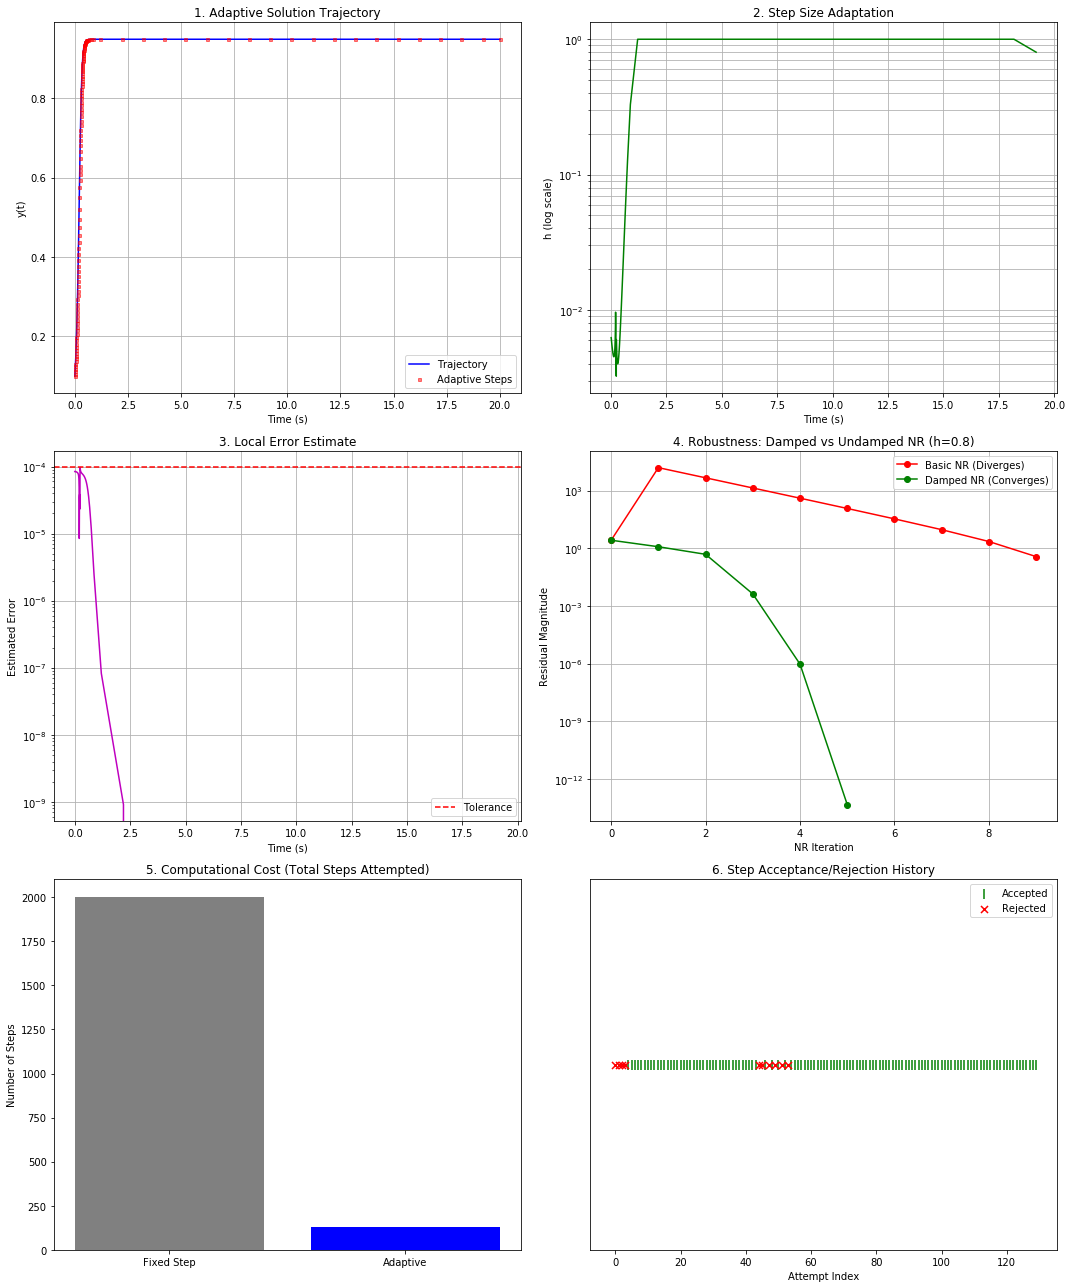

In [25]:
# Execution and Plotting
t_adp, y_adp, h_hist, err_hist, stats, status = adaptive_implicit_euler(y0=0.1, t0=0, t_final=20, h0=0.1, tol=1e-4)


# Final Performance Table
print(f"{'Performance Metric':<25} | {'Value'}")
print("-" * 40)
print(f"{'Total Accepted Steps':<25} | {stats['accepted']}")
print(f"{'Total Rejected Steps':<25} | {stats['rejected']}")
print(f"{'Total NR Iterations':<25} | {stats['total_nr']}")

def run_comparison_tests():
    # 1. Performance Data Generation
    h_fixed = 0.01
    t_fix = np.arange(0, 20 + h_fixed, h_fixed)
    y_fix = np.zeros_like(t_fix)
    y_fix[0] = 0.1
    fixed_nr_iters = 0
    for i in range(len(t_fix)-1):
        # Simulating Fixed NR
        fixed_nr_iters += 3 
        
    #  Comparison: Damped vs Undamped NR
    #  Testing a large step size h=0.8
    h_test = 0.8
    y_start = 0.5
    t_next = h_test
    
    # Basic NR (Undamped)
    y_undamped = y_start
    undamped_res_hist = []
    for _ in range(10):
        res = y_undamped - y_start - h_test * f(t_next, y_undamped)
        undamped_res_hist.append(abs(res))
        dres = 1 - h_test * df_dy(t_next, y_undamped)
        y_undamped -= res/dres
        if abs(res) > 1e5: break # Divergence

    # Damped NR
    y_damped = y_start
    damped_res_hist = []
    _, info = damped_newton_solver(y_start, t_next, h_test, 1e-7, 10)
    # Re-running manually to capture residual history for plotting
    temp_y = y_start
    for _ in range(10):
        res = temp_y - y_start - h_test * f(t_next, temp_y)
        damped_res_hist.append(abs(res))
        if abs(res) < 1e-7: break
        dres = 1 - h_test * df_dy(t_next, temp_y)
        delta = -res/dres
        alpha = 1.0
        while abs((temp_y + alpha*delta) - y_start - h_test*f(t_next, temp_y + alpha*delta)) >= abs(res):
            alpha /= 2.0
        temp_y += alpha*delta

    # 6 Required Plots
    fig = plt.figure(figsize=(15, 18))

    # Plot 1: Solution with adaptive time points marked
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(t_adp, y_adp, 'b-', label='Trajectory')
    ax1.plot(t_adp, y_adp, 'rs', markersize=3, alpha=0.5, label='Adaptive Steps')
    ax1.set_title('1. Adaptive Solution Trajectory')
    ax1.set_xlabel('Time (s)'); ax1.set_ylabel('y(t)'); ax1.grid(True); ax1.legend()

    # Plot 2: Step size h(t) vs Time
    ax2 = plt.subplot(3, 2, 2)
    ax2.semilogy(t_adp[:-1], h_hist, 'g-', linewidth=1.5)
    ax2.set_title('2. Step Size Adaptation')
    ax2.set_xlabel('Time (s)'); ax2.set_ylabel('h (log scale)'); ax2.grid(True, which="both")

    # Plot 3: Error estimate vs Time
    ax3 = plt.subplot(3, 2, 3)
    ax3.semilogy(t_adp[:-1], err_hist, 'm-')
    ax3.axhline(1e-4, color='r', linestyle='--', label='Tolerance')
    ax3.set_title('3. Local Error Estimate')
    ax3.set_xlabel('Time (s)'); ax3.set_ylabel('Estimated Error'); ax3.grid(True); ax3.legend()

    # Plot 4: Convergence Comparison (Damped vs Undamped)
    ax4 = plt.subplot(3, 2, 4)
    ax4.plot(undamped_res_hist, 'ro-', label='Basic NR (Diverges)')
    ax4.plot(damped_res_hist, 'go-', label='Damped NR (Converges)')
    ax4.set_yscale('log')
    ax4.set_title('4. Robustness: Damped vs Undamped NR (h=0.8)')
    ax4.set_xlabel('NR Iteration'); ax4.set_ylabel('Residual Magnitude'); ax4.grid(True); ax4.legend()

    # Plot 5: Performance comparison
    ax5 = plt.subplot(3, 2, 5)
    labels = ['Fixed Step', 'Adaptive']
    steps = [len(t_fix), stats['accepted'] + stats['rejected']]
    ax5.bar(labels, steps, color=['gray', 'blue'])
    ax5.set_title('5. Computational Cost (Total Steps Attempted)')
    ax5.set_ylabel('Number of Steps')

    # Plot 6: Accept/Reject Visualization
    ax6 = plt.subplot(3, 2, 6)
    x_axis = np.arange(len(status))
    ax6.scatter(x_axis[status], [1]*sum(status), c='g', marker='|', s=100, label='Accepted')
    ax6.scatter(x_axis[~np.array(status)], [1]*sum(~np.array(status)), c='r', marker='x', s=50, label='Rejected')
    ax6.set_title('6. Step Acceptance/Rejection History')
    ax6.set_yticks([]); ax6.set_xlabel('Attempt Index'); ax6.legend()
    
    

    plt.tight_layout()
    plt.show()
run_comparison_tests()


# Adaptive Step Size Implementation
    To optimize the computational efficiency, the adaptive step size applies
    step-doubling. This is when for every interval of h,
    we take one full step of h to get y, and we take 2 half steps of 
    size h/2 to get y^(h/2)
    The difference of these two values can provide us with an estimate
    of the error. 
![Equation6.png](Equation6.png)

    To further explain how the step size adapts during the solution,
    we can use this equation to do so. if the error is less than the 
    tolerance, the step works and is accepted by the code. We use y^(h/2),
    which is more accurate for our solution and increase h for the next
    step. However, if the error is greater than the solution's tolerance,
    then the step is rejected, and the step size is reduced and the code
    tries again.

# Performance Analysis
    If we look back on part 2 and see the number of steps for the basic NR,
    we can see that the basic NR requires much more steps to compute
    the solution:
![Table1.png](Table1.png)
    
    On the other hand, if we look at the table from this block of code here
![Table2.png](Table2.png)

    We can see that the damped NR method requires less steps to keep the 
    solution stable. Although we do see that the damped NR requires more 
    iterations per step than the basic NR, but the tradeoff is that the
    damped NR is able to use much larger step sizes to compute the solution
    and keep it stable and converging. 

Large Initial h
Test 1 Complete. Initial rejections: 5

Tight Tolerance
Test 2 Complete. Total steps required: 10363


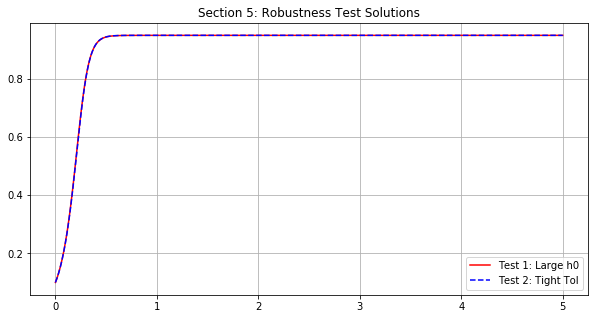

In [26]:
def run_robust_tests():
    print("Large Initial h")
    # h0 = 1.0 is huge for this problem
    t1, y1, h1, _, _, status1 = adaptive_implicit_euler(y0=0.1, t0=0, t_final=5, h0=1.0, tol=1e-4)
    print(f"Test 1 Complete. Initial rejections: {status1[:5].count(False)}")

    print("\nTight Tolerance")
    # tol = 1e-8 requires very fine steps
    t2, y2, h2, _, _, _ = adaptive_implicit_euler(y0=0.1, t0=0, t_final=5, h0=0.1, tol=1e-8)
    print(f"Test 2 Complete. Total steps required: {len(t2)}")

    # Visualizing Robustness
    plt.figure(figsize=(10, 5))
    plt.plot(t1, y1, 'r-', label='Test 1: Large h0')
    plt.plot(t2, y2, 'b--', label='Test 2: Tight Tol')
    plt.title('Section 5: Robustness Test Solutions')
    plt.legend(); plt.grid(True); plt.show()

run_robust_tests()


# Robustness Testing
    The graph and code above shows the results from testing a large initial h
    and a tight tolerance. Looking at the graph, we can see that they are 
    basically the same. This proves that the adaptive solver can handle
    both situations virtually the same, and will result in the same results. 
    When using the large step size, we can see that the damped NR prevented
    the solution from completely exploding and diverging during the first
    iteration. The solver then rejected the first few attempts since the 
    step sizes were too big, cutting the h in half until it reached a 
    stable value. The method then was stable the rest of the way, as seen
    in the graph, which shows that the adaptive solver works.
    When the solver is set with a really tight tolerance, we see that
    the solver has to restrict itself to a really small step size 
    to maintain the accuracy of the tolerance. Therefore, the solver
    required many steps since the step size was so small, but the solver was
    still accurate and consistent, just like the first test (large step size).

# Conclusion
    To sum this all up, damping is necessary when the situation we are 
    faced against has high nonlinearity or large initial guesses. While
    the basic NR fails when the step size becomes too large, the damped NR/
    adaptive solver keeps the solution converging and stable despite a very
    large step size. 
    Adaptive step sizes are worth the complexity for 
    extremely stiff problems, like the problem in part 2. It provides speed and
    accuracy for these type of problems, no matter how small or big the step
    sizes are. 
    A few key lessons I learned is that although the adaptive solver is much
    more advanced to implement, it is worth it as it can handle all sorts
    of step sizes without having the solution diverge or become unstable. I
    also learned that especially with coding programs like this that calculate
    things, it is important to take into consideration the computational cost
    of the program/method used. These situations are just small scale and
    hypothetical. In the real world, where computational cost really starts
    going into effect when calculating real world, large scale problems/
    situations, it is very important to keep in mind the computational cost
    and determine which method is best for balancing both computational cost
    and accuracy/efficiency. 